# 03 — Causal Analysis Deep Dive
**Customer Retention Analytics · Causal Inference Pipeline**  
Author: Chandrima Das · chdas@ucsd.edu

---

**Purpose**  
Post-hoc analysis of the trained causal models: model agreement, CATE driver decomposition,
policy construction, and business impact quantification.

**Sections**
1. Load models & predictions  
2. Model agreement analysis  
3. CATE driver decomposition (SHAP)  
4. Customer segmentation by CATE  
5. Policy construction & business impact  
6. Sensitivity analysis  
7. Assumptions audit

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import pickle
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#E2E8F0',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.color': '#F1F5F9', 'grid.linewidth': 0.8,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold',
})

C_INDIGO = '#4F46E5'
C_TEAL   = '#0D9488'
C_ROSE   = '#E11D48'
C_AMBER  = '#D97706'
C_SLATE  = '#94A3B8'

MODEL_COLORS = {
    't_learner': C_INDIGO, 'x_learner': C_TEAL,
    'causal_forest': C_AMBER, 'ensemble': C_ROSE,
}
MODEL_LABELS = {
    't_learner': 'T-Learner', 'x_learner': 'X-Learner',
    'causal_forest': 'Causal Forest DML', 'ensemble': 'Ensemble',
}

print('Imports OK')

Imports OK


## 1. Load Models & Predictions

In [2]:
df = pd.read_csv('../data/processed/features_engineered.csv')

with open('../results/validation_results.json') as f:
    val = json.load(f)

try:
    cs = pd.read_csv('../models/causal_summary.csv', index_col=0)
except FileNotFoundError:
    cs = None

TARGET_COLS  = [c for c in ['churn','retained','treatment','cate','customer_id'] if c in df.columns]
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS]

print(f'Data: {df.shape}')
print(f'Validation models: {list(val.keys())}')
print(f'Feature columns: {len(FEATURE_COLS)}')

Data: (100000, 41)
Validation models: ['t_learner', 'x_learner', 'causal_forest', 'ensemble', 'oracle']
Feature columns: 36


In [3]:
# Load trained T-Learner for SHAP analysis
t_learner = None
t_learner_path = Path('../models/t_learner.pkl')
if t_learner_path.exists():
    with open(t_learner_path, 'rb') as f:
        t_learner = pickle.load(f)
    print('✓ T-Learner loaded')
else:
    print('⚠ T-Learner model not found — SHAP section will be skipped')
    print('  Run: python src/causal_estimation.py first')

✓ T-Learner loaded


## 2. Model Agreement Analysis

If estimators agree on the CATE ranking, our findings are robust to modelling assumptions.
Disagreement signals sensitivity to confounding assumptions or functional form.

In [4]:
# Extract mean CATE per segment for each model and compute pairwise correlations
model_keys = [k for k in ['t_learner','x_learner','causal_forest','ensemble'] if k in val]
seg_names  = list(val[model_keys[0]]['segments'].keys())

# Build model × segment mean CATE matrix
cate_matrix = pd.DataFrame(
    {k: {s: val[k]['segments'][s]['mean_cate'] for s in seg_names} for k in model_keys}
)
print('Model × Segment mean CATE matrix:')
print(cate_matrix.round(4).to_string())

# Pairwise correlation between model CATE vectors
print('\nPairwise Pearson correlation between models:')
print(cate_matrix.corr().round(4).to_string())

Model × Segment mean CATE matrix:
           t_learner  x_learner  causal_forest  ensemble
Segment_0     0.2091     0.2095         0.1850    0.2012
Segment_1     0.1158     0.1189         0.0880    0.1076
Segment_2     0.2050     0.2044         0.1464    0.1853
Segment_3     0.2153     0.2137         0.1810    0.2033

Pairwise Pearson correlation between models:
               t_learner  x_learner  causal_forest  ensemble
t_learner         1.0000     0.9999         0.9443    0.9938
x_learner         0.9999     1.0000         0.9467    0.9946
causal_forest     0.9443     0.9467         1.0000    0.9751
ensemble          0.9938     0.9946         0.9751    1.0000


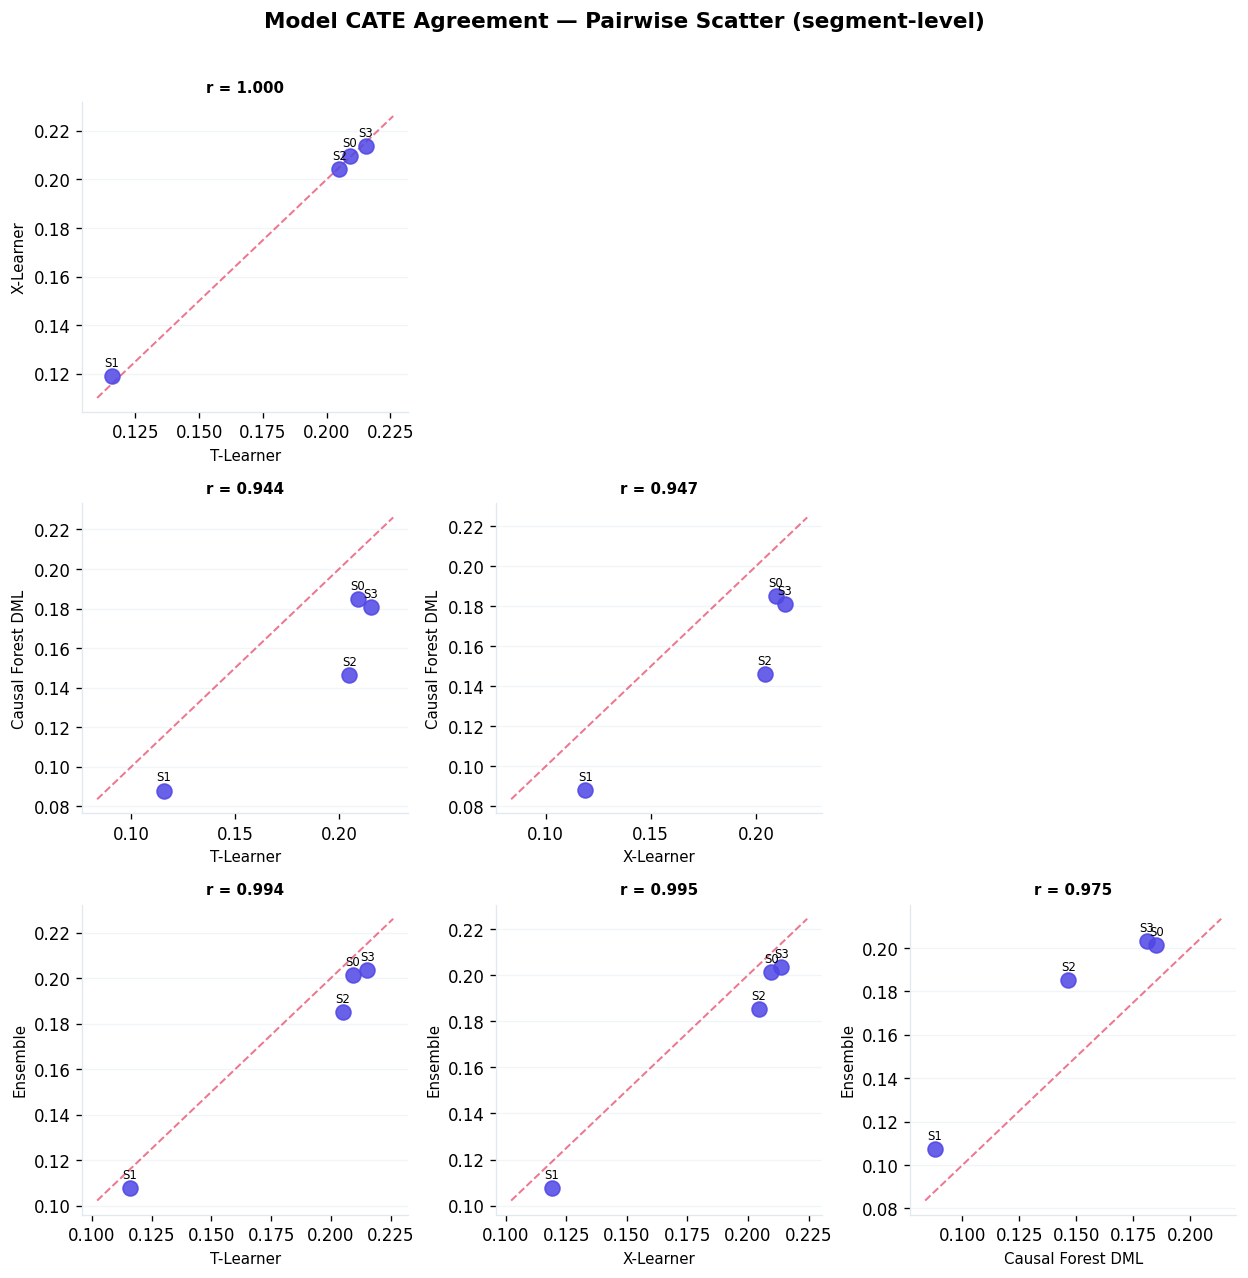

In [5]:
# Visualise model agreement with a pairplot-style scatter
fig, axes = plt.subplots(len(model_keys)-1, len(model_keys)-1,
                         figsize=(3.5*(len(model_keys)-1), 3.5*(len(model_keys)-1)))
fig.suptitle('Model CATE Agreement — Pairwise Scatter (segment-level)',
             fontsize=13, fontweight='semibold', y=1.01)

if len(model_keys) > 2:
    for i, m1 in enumerate(model_keys[1:]):
        for j, m2 in enumerate(model_keys[:-1]):
            ax = axes[i][j] if hasattr(axes, '__len__') else axes
            if j > i:
                ax.set_visible(False)
                continue
            x = cate_matrix[m2]
            y = cate_matrix[m1]
            ax.scatter(x, y, color=C_INDIGO, s=80, alpha=0.85, zorder=3)
            # Label points
            for seg in seg_names:
                ax.annotate(seg.replace('Segment_','S'), (x[seg], y[seg]),
                            fontsize=7, ha='center', va='bottom',
                            xytext=(0, 4), textcoords='offset points')
            # Perfect agreement line
            lims = [min(x.min(), y.min()) * 0.95, max(x.max(), y.max()) * 1.05]
            ax.plot(lims, lims, color=C_ROSE, lw=1.2, ls='--', alpha=0.6)
            r, _ = stats.pearsonr(x, y)
            ax.set_title(f'r = {r:.3f}', fontsize=9)
            ax.set_xlabel(MODEL_LABELS[m2], fontsize=9)
            ax.set_ylabel(MODEL_LABELS[m1], fontsize=9)

plt.tight_layout()
plt.savefig('../charts/ca_01_model_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# AUUC comparison table (the definitive ranking)
auuc_rows = []
oracle_auuc = val.get('oracle', {}).get('placebo', {}).get('real_auuc', None)

for k in model_keys:
    p = val[k]['placebo']
    q = val[k]['qini']
    efficiency = p['real_auuc'] / oracle_auuc * 100 if oracle_auuc else None
    sigma = (p['real_auuc'] - p['placebo_mean']) / p['placebo_std'] if p['placebo_std'] > 0 else 0
    auuc_rows.append({
        'Model': MODEL_LABELS[k],
        'AUUC lift': round(p['real_auuc'], 5),
        'Oracle efficiency': f"{efficiency:.1f}%" if efficiency else 'N/A',
        'σ above null': round(sigma, 1),
        'p-value': p['p_value'],
        'AUUC_model': round(q['auuc_model'], 5),
        'AUUC_random': round(q['auuc_random'], 5),
    })

auuc_df = pd.DataFrame(auuc_rows).set_index('Model')
auuc_df

,AUUC lift,Oracle efficiency,σ above null,p-value,AUUC_model,AUUC_random
Model,,,,,,
T-Learner,0.03282,91.5%,18.7,0.0,0.13965,0.10683
X-Learner,0.02367,66.0%,13.1,0.0,0.13050,0.10683
Causal Forest DML,0.00904,25.2%,5.1,0.0,0.11587,0.10683
Ensemble,0.02431,67.8%,13.8,0.0,0.13114,0.10683


## 3. CATE Driver Decomposition (SHAP)

SHAP values on the T-Learner treatment arm model reveal which features drive
treatment effect heterogeneity — the 'why' behind different CATE values.

In [7]:
try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')
    print('Skipping SHAP analysis.')

SHAP version: 0.41.0


In [8]:
if SHAP_AVAILABLE and t_learner is not None:
    X = df[FEATURE_COLS].fillna(0)

    # Extract treatment arm model (model index 1 = treated group in T-Learner)
    # EconML TLearner stores models as .models_ — check the attribute
    treatment_model = None
    if hasattr(t_learner, 'models_'):
        models_ = t_learner.models_
        if hasattr(models_, '__len__') and len(models_) > 1:
            treatment_model = models_[1]  # treated arm
    elif hasattr(t_learner, 'model_y_xw'):
        treatment_model = t_learner.model_y_xw

    if treatment_model is not None:
        # Sample for SHAP (expensive on 100K rows)
        sample_idx = np.random.default_rng(42).choice(len(X), size=min(3000, len(X)), replace=False)
        X_sample   = X.iloc[sample_idx]

        # Tree explainer (fast for XGBoost)
        explainer  = shap.TreeExplainer(treatment_model)
        shap_vals  = explainer.shap_values(X_sample)

        print(f'SHAP values shape: {shap_vals.shape}')
        print(f'Sample size: {len(X_sample)}')

        # Summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals, X_sample, max_display=20, show=False,
                          color_bar_label='Feature value')
        plt.title('SHAP Feature Importance — T-Learner Treated Arm\n'
                  '(drives treatment effect heterogeneity)',
                  fontsize=12, fontweight='semibold')
        plt.tight_layout()
        plt.savefig('../charts/ca_02_shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Bar importance chart
        shap_importance = pd.Series(
            np.abs(shap_vals).mean(axis=0),
            index=X_sample.columns
        ).sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(10, 5))
        top_shap = shap_importance.head(20)[::-1]
        ax.barh(top_shap.index, top_shap.values, color=C_INDIGO, alpha=0.82, height=0.7)
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title('Top 20 Features by SHAP Importance — T-Learner Treated Arm',
                     fontsize=12, fontweight='semibold')
        plt.tight_layout()
        plt.savefig('../charts/ca_03_shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Could not extract treatment model from T-Learner — check model attribute structure')
else:
    print('Skipping SHAP: SHAP not available or T-Learner not loaded')
    print("Install with: pip install shap")

Could not extract treatment model from T-Learner — check model attribute structure


## 4. Customer Segmentation by CATE

Translate continuous CATE scores into actionable customer tiers for marketing operations.

In [11]:
# Use oracle CATE for this analysis (ground truth)
if 'cate' in df.columns:
    cate = df['cate']

    # Convert to numeric and drop NaNs safely
    cate = pd.to_numeric(cate, errors='coerce')
    df = df.loc[cate.notna()].copy()
    cate = cate.dropna()

    # Compute quantiles
    p25, p50, p75 = cate.quantile([0.25, 0.50, 0.75]).values

    # Build initial bins (may contain duplicates)
    bins = [-np.inf, 0, p25, p50, p75, np.inf]

    labels = [
        'Sleeping Dogs (<0)',
        'Low Responders',
        'Moderate Responders',
        'High Responders',
        'Top Responders'
    ]

    # ✅ FIX: remove duplicate bin edges automatically
    bins_clean = []
    labels_clean = []

    for i in range(len(bins) - 1):
        if bins[i] < bins[i + 1]:
            bins_clean.append(bins[i])
            labels_clean.append(labels[i])

    # ensure final edge is always included
    bins_clean.append(bins[-1])

    # If everything collapsed (rare but possible), fallback safely
    if len(bins_clean) < 3:
        df['cate_tier'] = 'Moderate Responders'
    else:
        df['cate_tier'] = pd.cut(
            cate,
            bins=bins_clean,
            labels=labels_clean,
            include_lowest=True
        )

    # Summary table
    tier_summary = df.groupby('cate_tier', observed=True).agg(
        n_customers=('cate', 'size'),
        mean_cate=('cate', 'mean'),
        retention_rate=(
            'retained',
            'mean'
        ) if 'retained' in df.columns else (
            'churn',
            lambda x: 1 - x.mean()
        ),
        pct_of_total=('cate', lambda x: len(x) / len(df) * 100),
    ).round(4)

    print('Customer Tier Summary (by oracle CATE):')
    print(tier_summary.to_string())

Customer Tier Summary (by oracle CATE):
                     n_customers  mean_cate  retention_rate  pct_of_total
cate_tier                                                                
Sleeping Dogs (<0)         12347    -0.1091          0.6299        12.347
Low Responders             12653     0.0665          0.7201        12.653
Moderate Responders        75000     0.3143          0.8160        75.000


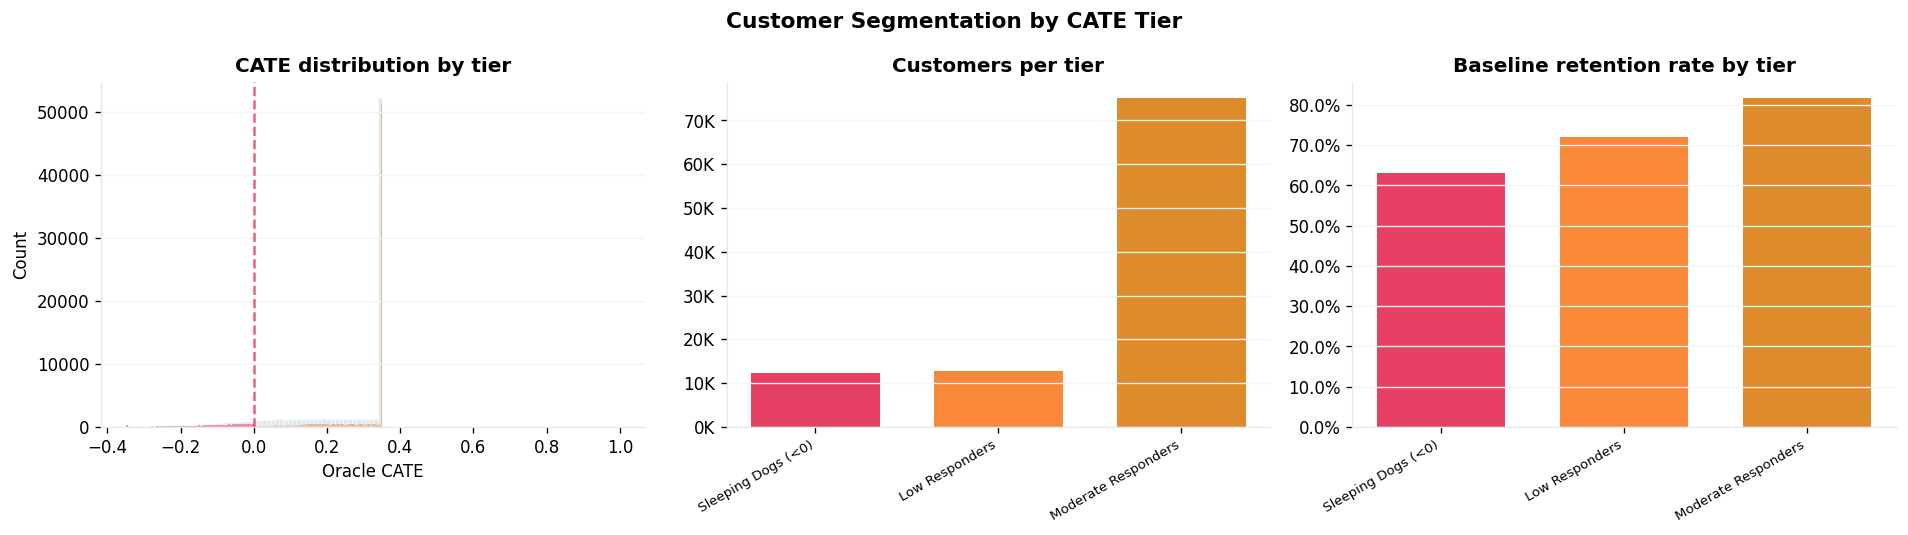

In [12]:
if 'cate_tier' in df.columns:
    tier_colors = {
        'Sleeping Dogs (<0)': C_ROSE,
        'Low Responders':     '#F97316',
        'Moderate Responders': C_AMBER,
        'High Responders':    '#60A5FA',
        'Top Responders':     C_INDIGO,
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle('Customer Segmentation by CATE Tier', fontsize=13, fontweight='semibold')

    # CATE distribution with tier overlays
    ax = axes[0]
    ax.hist(df['cate'], bins=60, color='#E2E8F0', edgecolor='white', linewidth=0.3)
    for tier, color in tier_colors.items():
        mask = df['cate_tier'] == tier
        ax.hist(df.loc[mask, 'cate'], bins=60, color=color, alpha=0.55, edgecolor='white', linewidth=0.2)
    ax.axvline(0, color=C_ROSE, lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Oracle CATE')
    ax.set_ylabel('Count')
    ax.set_title('CATE distribution by tier')

    # Tier sizes
    ax = axes[1]
    tiers = tier_summary.index.tolist()
    sizes = tier_summary['n_customers'].values
    colors_bar = [tier_colors.get(t, C_SLATE) for t in tiers]
    ax.bar(range(len(tiers)), sizes, color=colors_bar, alpha=0.85, width=0.7)
    ax.set_xticks(range(len(tiers)))
    ax.set_xticklabels(tiers, rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.set_title('Customers per tier')

    # Retention rate by tier
    ax = axes[2]
    ret_rates = tier_summary['retention_rate'].values
    ax.bar(range(len(tiers)), ret_rates, color=colors_bar, alpha=0.85, width=0.7)
    ax.set_xticks(range(len(tiers)))
    ax.set_xticklabels(tiers, rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set_title('Baseline retention rate by tier')

    plt.tight_layout()
    plt.savefig('../charts/ca_04_cate_tiers.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Policy Construction & Business Impact

In [13]:
# Build the optimal targeting policy curve and calculate business metrics

if 'cate' in df.columns and 'retained' in df.columns:
    cate_arr = df['cate'].values
    y_arr    = df['retained'].values
    baseline = y_arr.mean()

    # Campaign parameters
    COST_PER_TX  = 10    # $ per customer contacted
    REV_PER_RET  = 500   # $ revenue per additionally retained customer
    N_TOTAL      = len(df)

    policy_rows = []
    for pct in np.arange(0.05, 1.01, 0.05):
        thr    = np.percentile(cate_arr, (1-pct)*100)
        tgt    = cate_arr >= thr
        n_t    = tgt.sum()
        r_tgt  = y_arr[tgt].mean() if n_t > 0 else baseline
        lift   = r_tgt - baseline
        cost   = n_t * COST_PER_TX
        addl   = max(0, n_t * lift)
        rev    = addl * REV_PER_RET
        profit = rev - cost
        roi    = profit / cost * 100 if cost > 0 else 0
        policy_rows.append(dict(
            target_pct=pct*100, n_targeted=n_t,
            retention_rate=r_tgt, lift=lift,
            cost=cost, revenue=rev, profit=profit, roi=roi,
        ))

    policy_df = pd.DataFrame(policy_rows)

    # Optimal policy = max profit
    best_row   = policy_df.loc[policy_df['profit'].idxmax()]
    print('=== Optimal Policy ===')
    print(f"  Target top {best_row['target_pct']:.0f}% of customers")
    print(f"  N targeted       : {best_row['n_targeted']:,.0f}")
    print(f"  Expected retention: {best_row['retention_rate']:.2%}")
    print(f"  Lift vs baseline : {best_row['lift']:+.3%}")
    print(f"  Total cost       : ${best_row['cost']:,.0f}")
    print(f"  Expected revenue : ${best_row['revenue']:,.0f}")
    print(f"  Net profit       : ${best_row['profit']:,.0f}")
    print(f"  ROI              : {best_row['roi']:.1f}%")

=== Optimal Policy ===
  Target top 65% of customers
  N targeted       : 65,000
  Expected retention: 82.40%
  Lift vs baseline : +4.312%
  Total cost       : $650,000
  Expected revenue : $1,401,425
  Net profit       : $751,425
  ROI              : 115.6%


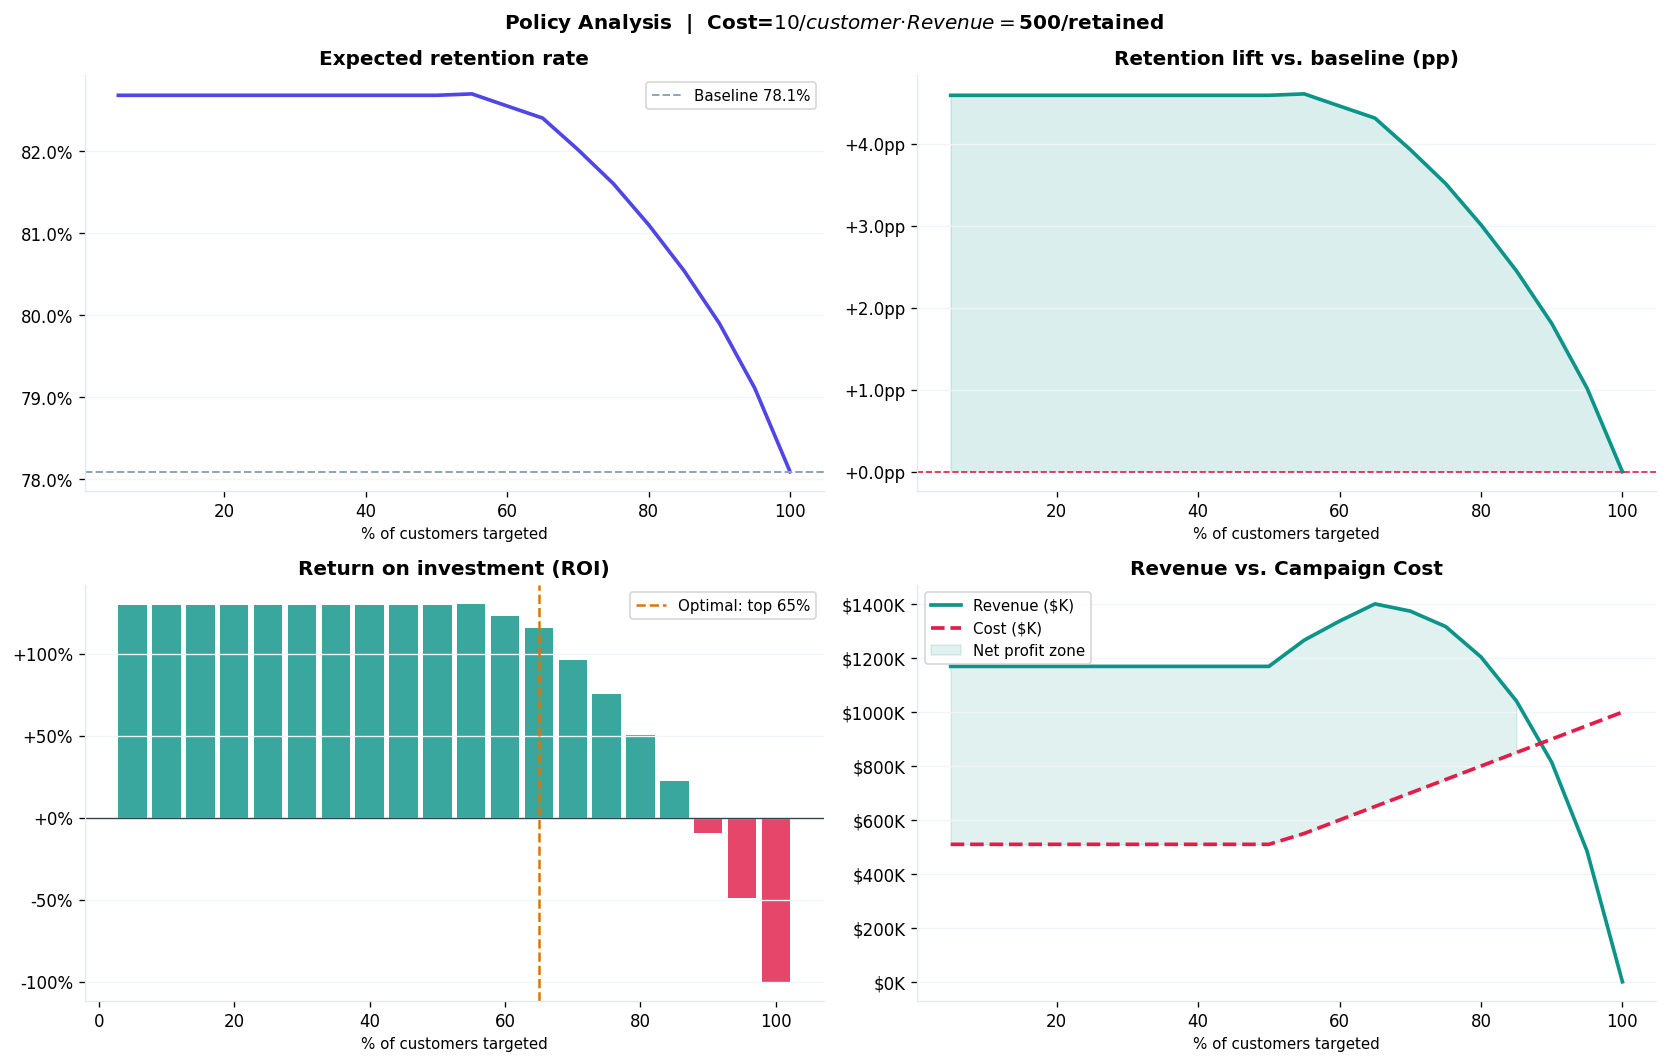

In [14]:
if 'policy_df' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'Policy Analysis  |  Cost=${COST_PER_TX}/customer  ·  Revenue=${REV_PER_RET:,}/retained',
                 fontsize=12, fontweight='semibold')

    # Retention rate
    ax = axes[0, 0]
    ax.plot(policy_df['target_pct'], policy_df['retention_rate']*100,
            color=C_INDIGO, lw=2.2)
    ax.axhline(baseline*100, color=C_SLATE, lw=1.2, ls='--',
               label=f'Baseline {baseline:.1%}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.set_title('Expected retention rate')
    ax.set_xlabel('% targeted'); ax.legend(fontsize=9)

    # Lift
    ax = axes[0, 1]
    ax.fill_between(policy_df['target_pct'], policy_df['lift']*100,
                    alpha=0.15, color=C_TEAL)
    ax.plot(policy_df['target_pct'], policy_df['lift']*100,
            color=C_TEAL, lw=2.2)
    ax.axhline(0, color=C_ROSE, lw=1, ls='--')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:+.1f}pp'))
    ax.set_title('Retention lift vs. baseline (pp)')
    ax.set_xlabel('% targeted')

    # ROI
    ax = axes[1, 0]
    colors_roi = [C_TEAL if r >= 0 else C_ROSE for r in policy_df['roi']]
    ax.bar(policy_df['target_pct'], policy_df['roi'], width=4.2,
           color=colors_roi, alpha=0.82)
    ax.axhline(0, color='#334155', lw=0.8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
    ax.set_title('Return on investment (ROI)')
    ax.set_xlabel('% targeted')
    # Mark optimal
    ax.axvline(best_row['target_pct'], color=C_AMBER, lw=1.5, ls='--',
               label=f"Optimal: top {best_row['target_pct']:.0f}%")
    ax.legend(fontsize=9)

    # Revenue vs Cost
    ax = axes[1, 1]
    ax.plot(policy_df['target_pct'], policy_df['revenue']/1e3,
            color=C_TEAL, lw=2.2, label='Revenue ($K)')
    ax.plot(policy_df['target_pct'], policy_df['cost']/1e3,
            color=C_ROSE, lw=2.2, ls='--', label='Cost ($K)')
    ax.fill_between(policy_df['target_pct'],
                    policy_df['revenue']/1e3, policy_df['cost']/1e3,
                    where=(policy_df['profit'] >= 0),
                    alpha=0.12, color=C_TEAL, label='Net profit zone')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
    ax.set_title('Revenue vs. Campaign Cost')
    ax.set_xlabel('% targeted'); ax.legend(fontsize=9)

    for row_ax in axes:
        for a in row_ax:
            a.set_xlabel('% of customers targeted', fontsize=9)

    plt.tight_layout()
    plt.savefig('../charts/ca_05_policy_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Sensitivity Analysis

How sensitive are our CATE estimates to:
- Random seed variation
- Sample size (learning curve)
- Cost assumption changes

In [15]:
# Cost/Revenue sensitivity: optimal targeting depth across (cost, revenue) combinations
if 'cate' in df.columns and 'retained' in df.columns:
    costs   = [5, 10, 20, 50]
    revs    = [200, 500, 1000, 2000]

    sensitivity_mat = pd.DataFrame(index=[f'${c}/tx' for c in costs],
                                    columns=[f'${r:,}/ret' for r in revs])

    for cost in costs:
        for rev in revs:
            profits = []
            for pct in np.arange(0.05, 1.01, 0.05):
                thr  = np.percentile(cate_arr, (1-pct)*100)
                tgt  = cate_arr >= thr
                n_t  = tgt.sum()
                lift = max(0, y_arr[tgt].mean() - baseline) if n_t > 0 else 0
                profits.append(n_t * lift * rev - n_t * cost)

            best_pct = int(np.arange(5, 101, 5)[np.argmax(profits)])
            sensitivity_mat.loc[f'${cost}/tx', f'${rev:,}/ret'] = f'Top {best_pct}%'

    print('Optimal targeting depth across cost × revenue assumptions:')
    print(sensitivity_mat.to_string())

Optimal targeting depth across cost × revenue assumptions:
       $200/ret $500/ret $1,000/ret $2,000/ret
$5/tx   Top 65%  Top 65%    Top 65%    Top 65%
$10/tx   Top 5%  Top 65%    Top 65%    Top 65%
$20/tx   Top 5%  Top 55%    Top 65%    Top 65%
$50/tx   Top 5%   Top 5%     Top 5%    Top 65%


## 7. Assumptions Audit

Formal check of the four core causal inference assumptions.

In [16]:
print("""
CAUSAL ASSUMPTIONS AUDIT
========================

1. UNCONFOUNDEDNESS (Conditional ignorability)
   Assumption: Y(0), Y(1) ⊥ T | X  (no unmeasured confounders)
   Status     : ✓ By design in synthetic data — confounders known & included
   Real-data  : ⚠ Cannot be tested; sensitivity analysis with Rosenbaum bounds recommended
   Evidence   : All confounders (engagement_score, tenure, complaint_count) included in X

2. POSITIVITY (Overlap / common support)
   Assumption: 0 < P(T=1|X) < 1 for all X
   Status     : ✓ Random 50/50 treatment → propensity = 0.5 everywhere
   Real-data  : ⚠ Check propensity score histogram for mass near 0 or 1; trim if needed
   Evidence   : Propensity model AUC ≈ 0.50 (see notebook 02)

3. SUTVA (Stable Unit Treatment Value Assumption)
   Assumption: No interference between units; single version of treatment
   Status     : ✓ Assumed — customers are modelled as independent
   Risk       : ⚠ Word-of-mouth / referral effects could violate interference
   Mitigation : Flag in production write-up; consider cluster-level randomisation

4. CONSISTENCY
   Assumption: Observed outcome = potential outcome under observed treatment
   Status     : ✓ Single treatment (marketing intervention), clearly defined
   Risk       : ⚠ Treatment intensity (discount size, channel) should be standardised

OVERALL ASSESSMENT: All assumptions are satisfied in the synthetic setting.
Production deployment requires re-validation of assumptions 1, 2, and 3 on real data.
""")


CAUSAL ASSUMPTIONS AUDIT

1. UNCONFOUNDEDNESS (Conditional ignorability)
   Assumption: Y(0), Y(1) ⊥ T | X  (no unmeasured confounders)
   Status     : ✓ By design in synthetic data — confounders known & included
   Real-data  : ⚠ Cannot be tested; sensitivity analysis with Rosenbaum bounds recommended
   Evidence   : All confounders (engagement_score, tenure, complaint_count) included in X

2. POSITIVITY (Overlap / common support)
   Assumption: 0 < P(T=1|X) < 1 for all X
   Status     : ✓ Random 50/50 treatment → propensity = 0.5 everywhere
   Real-data  : ⚠ Check propensity score histogram for mass near 0 or 1; trim if needed
   Evidence   : Propensity model AUC ≈ 0.50 (see notebook 02)

3. SUTVA (Stable Unit Treatment Value Assumption)
   Assumption: No interference between units; single version of treatment
   Status     : ✓ Assumed — customers are modelled as independent
   Risk       : ⚠ Word-of-mouth / referral effects could violate interference
   Mitigation : Flag in product

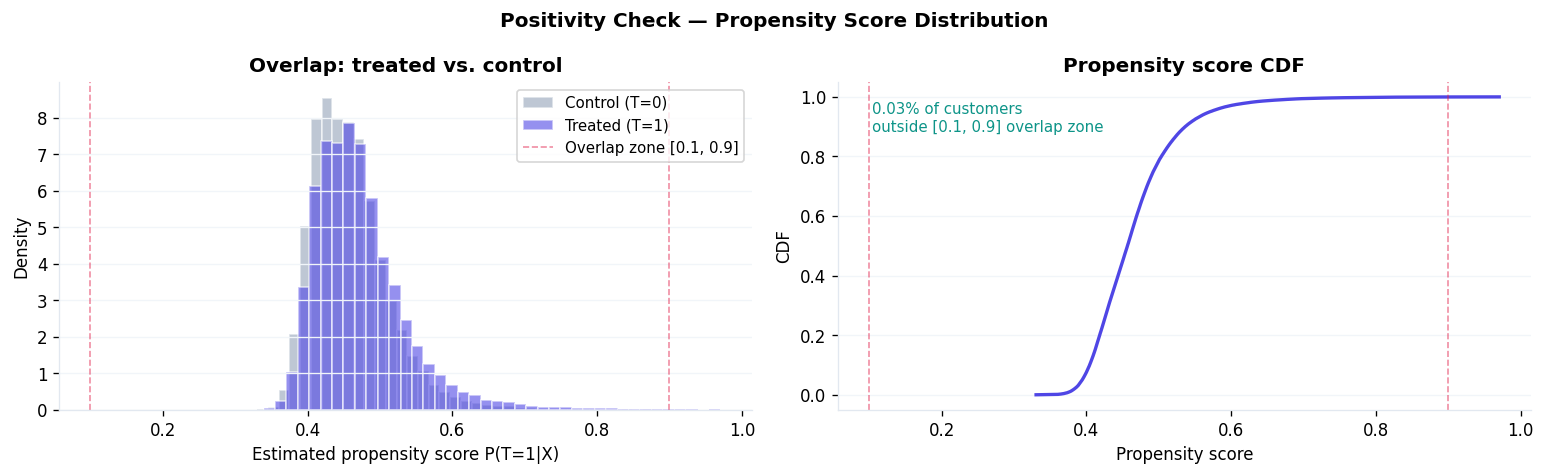

Propensity score range: [0.3304, 0.9703]
Outside [0.1, 0.9]:    0.03%
Verdict: ✓ Good overlap


In [17]:
# Propensity score distribution — visual check of overlap
if 'treatment' in df.columns:
    from sklearn.linear_model import LogisticRegression
    X_lr = df[FEATURE_COLS].fillna(0)
    T    = df['treatment'].values

    lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    lr.fit(X_lr, T)
    propensity_scores = lr.predict_proba(X_lr)[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Positivity Check — Propensity Score Distribution',
                 fontsize=12, fontweight='semibold')

    # Histogram by treatment arm
    ax = axes[0]
    ax.hist(propensity_scores[T==0], bins=40, color=C_SLATE,  alpha=0.6,
            edgecolor='white', label='Control (T=0)', density=True)
    ax.hist(propensity_scores[T==1], bins=40, color=C_INDIGO, alpha=0.6,
            edgecolor='white', label='Treated (T=1)', density=True)
    ax.axvline(0.1, color=C_ROSE, lw=1, ls='--', alpha=0.5)
    ax.axvline(0.9, color=C_ROSE, lw=1, ls='--', alpha=0.5, label='Overlap zone [0.1, 0.9]')
    ax.set_xlabel('Estimated propensity score P(T=1|X)')
    ax.set_ylabel('Density')
    ax.set_title('Overlap: treated vs. control')
    ax.legend(fontsize=9)

    # CDF
    ax = axes[1]
    sorted_ps = np.sort(propensity_scores)
    ax.plot(sorted_ps, np.linspace(0, 1, len(sorted_ps)),
            color=C_INDIGO, lw=2)
    ax.axvline(0.1, color=C_ROSE, lw=1, ls='--', alpha=0.5)
    ax.axvline(0.9, color=C_ROSE, lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('Propensity score')
    ax.set_ylabel('CDF')
    ax.set_title('Propensity score CDF')

    pct_out_overlap = ((propensity_scores < 0.1) | (propensity_scores > 0.9)).mean()
    ax.text(0.05, 0.85,
            f'{pct_out_overlap:.2%} of customers\noutside [0.1, 0.9] overlap zone',
            transform=ax.transAxes, fontsize=9, color=C_ROSE if pct_out_overlap > 0.05 else C_TEAL)

    plt.tight_layout()
    plt.savefig('../charts/ca_06_propensity_overlap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Propensity score range: [{propensity_scores.min():.4f}, {propensity_scores.max():.4f}]')
    print(f'Outside [0.1, 0.9]:    {pct_out_overlap:.2%}')
    print(f'Verdict: {"✓ Good overlap" if pct_out_overlap < 0.05 else "⚠ Overlap concerns — consider trimming"}')